Everything imported from

https://pennylane.ai/devices/

In [22]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# Simulators

In [23]:
# Written in Python, more complete, perfect for learning
dev_python = qml.device("default.qubit", wires=2, shots=1)#Name, number of qubits and shots

# High performance for training, written in C++
dev_Cplusplus = qml.device("lightning.qubit", wires=2, shots=1)

# For mixed states, to see how it works with noise
dev_mixed = qml.device("default.mixed", wires=2, shots=1)

/home/mikel/QuantumComputing/QMLvenv/lib/python3.12/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


# Real Hardware (need plugins)

In [24]:
# Send to IBM computers, (need pip install pennylane-qiskit)
# dev_ibm = qml.device("qiskit.remote", wires=2, shots=1)


# dev_ionq = qml.device("ionq.qpu", wires=2, shots=1)
# dev_amazon = qml.device("braket.aws.qubit", wires=2, shots=1)
# dev_rigetti = qml.device("rigetti.qpu", wires=2, shots=1)

# Testing

In [25]:
dev = qml.device('default.qubit', wires=2)

@qml.qnode(dev)
def circuit():
    qml.Hadamard(wires=0) 
    return qml.expval(qml.PauliZ(0)) # Measure expected value in Z of qubit 0

print(circuit())

0.0


The result of the measurement is: 0.8577
Gradient of the circuit respect to [weight_0, weight_1]: [-5.14135992e-01  6.93889390e-18]

Visual Diagrama:
0: ──RX(0.54)─╭●─┤  <Z>
1: ──RY(0.12)─╰X─┤     


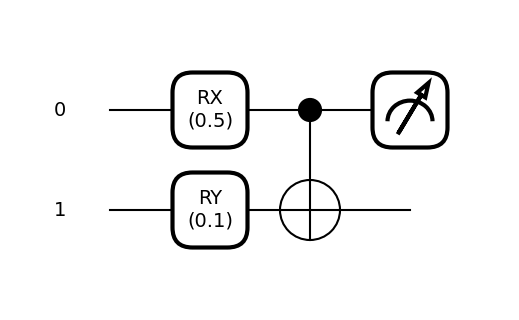

In [32]:
@qml.qnode(dev)
def circuit_qml(parameters):
    
    # Rotacion gates
    qml.RX(parameters[0], wires=0)
    qml.RY(parameters[1], wires=1)
    
    # CNOT in qubits 0 and 1
    qml.CNOT(wires=[0, 1])
    
    return qml.expval(qml.PauliZ(0))

# Initialize angles
angles = np.array([0.54, 0.12], requires_grad=True) # requires_grad=True to enable Machine Learning

# Execute
result = circuit_qml(angles)
print(f"The result of the measurement is: {result:.4f}")

# Gradients

gradient_function = qml.grad(circuit_qml)
gradient = gradient_function(angles)
print(f"Gradient of the circuit respect to [weight_0, weight_1]: {gradient}")

# Draw
print("\nVisual Diagrama:")
print(qml.draw(circuit_qml)(angles))

# Draw with matplotlib
qnode = qml.QNode(circuit_qml, dev)
qml.draw_mpl(qnode, decimals=1, style="black_white")(angles)
plt.show()

# Transform external circuits

Transform Qiskit circuit into Pennylane circuit (Rigetti also available)

2.220446049250313e-16


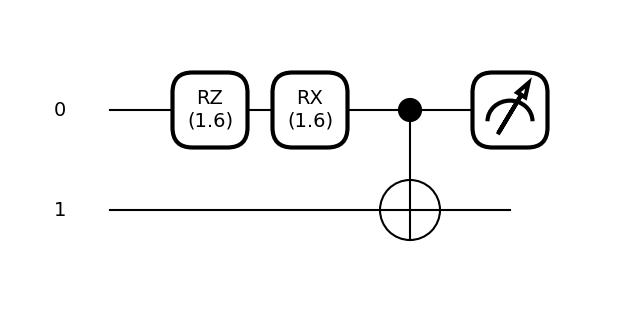

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
import numpy as np

dev = qml.device('default.qubit', wires=2)

theta = Parameter('θ')

qc = QuantumCircuit(2)
qc.rz(theta, [0])
qc.rx(theta, [0])
qc.cx(0, 1)

@qml.qnode(dev)
def quantum_circuit_with_loaded_subcircuit(x):
    qml.from_qiskit(qc)({theta: x}) # from_qasm, from_pyquil, from_quil, from_quil_file
    return qml.expval(qml.PauliZ(0))

angle = np.pi/2
result = quantum_circuit_with_loaded_subcircuit(angle)
print(result)

qnode = qml.QNode(quantum_circuit_with_loaded_subcircuit, dev)
qml.draw_mpl(qnode, decimals=1, style="black_white")(angle)
plt.show()

# Create new custom device

For defining a custom device

In [39]:
from pennylane.devices import Device, ExecutionConfig
from pennylane.tape import QuantumScript, QuantumScriptOrBatch

class MyDevice(Device):
    """My Documentation."""

    def execute(
        self,
        circuits: QuantumScriptOrBatch,
        execution_config: ExecutionConfig | None = None
    ):
        # your implementation here
        return 0

For example

In [41]:
class MyDevice(Device):
    """My Documentation."""

    def execute(
        self,
        circuits: QuantumScriptOrBatch,
        execution_config: ExecutionConfig | None = None
    ):
        return 0.0 if isinstance(circuits, qml.tape.QuantumScript) else tuple(0.0 for c in circuits)

dev = MyDevice()

@qml.qnode(dev)
def circuit():
    return qml.state()

circuit()

0.0